In [ ]:
# ENVIRONMENT SETUP
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [ ]:
# DATASET LOADING
#  Load dataset

data = pd.read_csv('/content/creditcard.csv')

In [ ]:
# Display dataset columns

data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
# Display first 5 rows of dataset

data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [ ]:
# Display dataset shape

data.shape

(160580, 31)

In [ ]:
# Display dataset information

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160580 entries, 0 to 160579
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    160580 non-null  float64
 1   V1      160580 non-null  float64
 2   V2      160580 non-null  float64
 3   V3      160580 non-null  float64
 4   V4      160580 non-null  float64
 5   V5      160580 non-null  float64
 6   V6      160580 non-null  float64
 7   V7      160580 non-null  float64
 8   V8      160580 non-null  float64
 9   V9      160580 non-null  float64
 10  V10     160579 non-null  float64
 11  V11     160579 non-null  float64
 12  V12     160579 non-null  float64
 13  V13     160579 non-null  float64
 14  V14     160579 non-null  float64
 15  V15     160579 non-null  float64
 16  V16     160579 non-null  float64
 17  V17     160579 non-null  float64
 18  V18     160579 non-null  float64
 19  V19     160579 non-null  float64
 20  V20     160579 non-null  float64
 21  V21     16

In [ ]:
# DATA PREPROCESSING
# Check missing values

data.isnull().sum()


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
# Check duplicate records

data.duplicated().sum()

np.int64(614)

In [ ]:
# Remove duplicate records

data = data.drop_duplicates()

In [ ]:
# Scale Amount and Time columns

scaler = StandardScaler()

data['scaled_amount'] = scaler.fit_transform(
    data[['Amount']]
)

data['scaled_time'] = scaler.fit_transform(
    data[['Time']]
)

In [ ]:
# Drop original Time and Amount columns

data = data.drop(['Time', 'Amount'], axis=1)

In [ ]:
# Verify missing values after preprocessing

data.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,1


In [ ]:
# Remove rows containing missing values

data = data.dropna()

In [ ]:
# Verify missing values after handling NaN values

data.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


In [ ]:
# Display processed dataset

data.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.0,0.253221,-2.332284
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0.0,-0.345330,-2.332284
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0.0,1.186267,-2.332243
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.0,0.146816,-2.332243
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.0,-0.071169,-2.332203


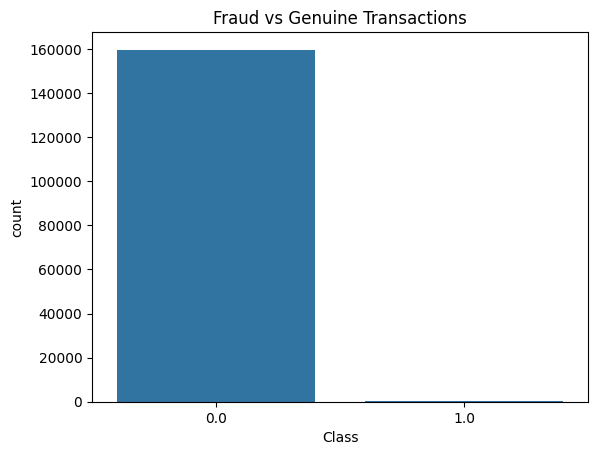

In [ ]:
# DATA VISUALIZATION
# Plot fraud vs genuine transactions

sns.countplot(x='Class', data=data)

plt.title("Fraud vs Genuine Transactions")

plt.show()

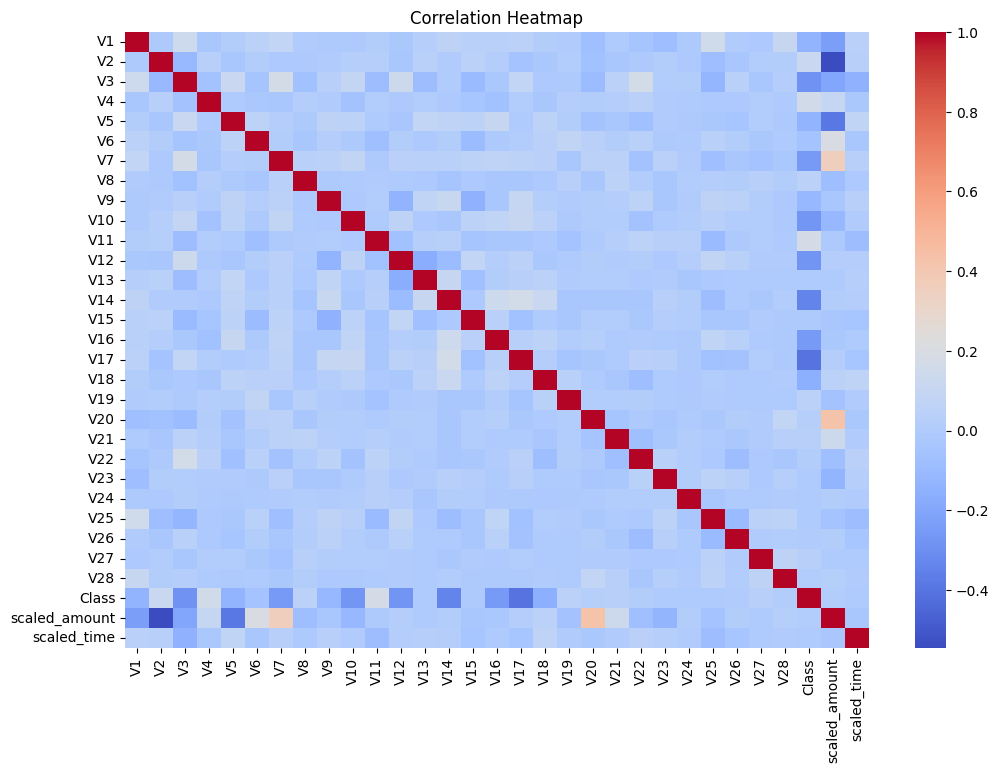

In [ ]:
# Plot correlation heatmap

plt.figure(figsize=(12,8))

sns.heatmap(data.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

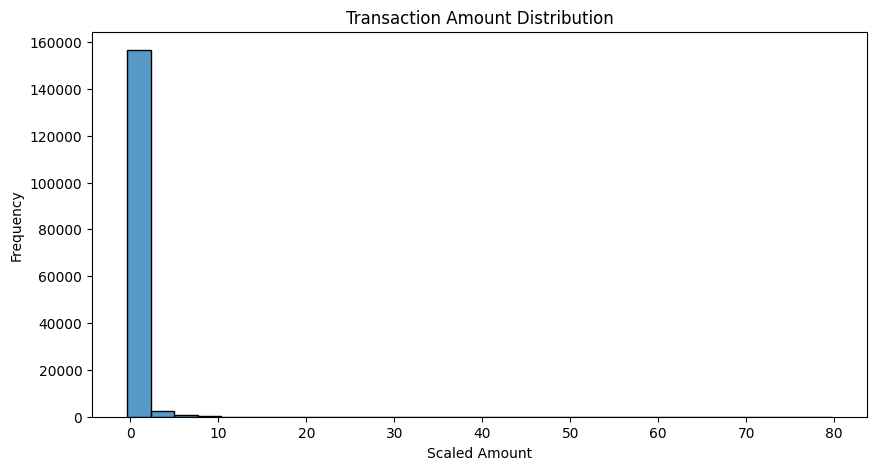

In [ ]:
# Plot transaction amount distribution

plt.figure(figsize=(10,5))

sns.histplot(data['scaled_amount'], bins=30)

plt.title("Transaction Amount Distribution")

plt.xlabel("Scaled Amount")

plt.ylabel("Frequency")

plt.show()

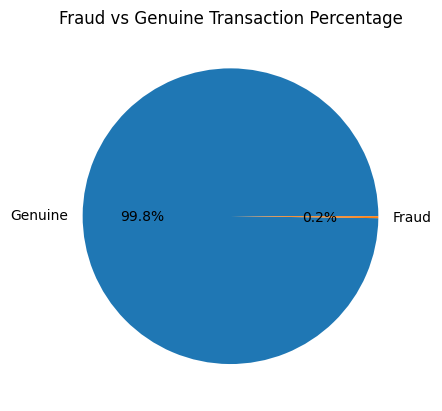

In [ ]:
# Plot fraud vs genuine transaction percentage

labels = ['Genuine', 'Fraud']

sizes = data['Class'].value_counts()

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Fraud vs Genuine Transaction Percentage")

plt.show()

In [ ]:
# Display correlation of features with Class

correlation = data.corr()['Class'].sort_values(ascending=False)

print(correlation)

Class            1.000000
V11              0.177210
V4               0.158913
V2               0.117443
V8               0.048479
V19              0.047957
V21              0.029098
V27              0.028739
V20              0.027170
V22              0.012704
V28              0.006546
scaled_amount    0.004868
V26              0.001840
V13             -0.002150
V25             -0.002283
scaled_time     -0.005692
V24             -0.006492
V23             -0.007741
V15             -0.010475
V6              -0.055657
V9              -0.112907
V5              -0.137674
V1              -0.138862
V18             -0.153063
V7              -0.249482
V16             -0.250630
V10             -0.271170
V12             -0.277366
V3              -0.281154
V14             -0.341038
V17             -0.405112
Name: Class, dtype: float64


In [ ]:
# MODEL IMPLEMENTATION
# Define input and output variables

X = data.drop('Class', axis=1)

y = data['Class']

In [ ]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Create Random Forest classifier model

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
# Train the model

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Predict test data

y_pred = model.predict(X_test)

In [ ]:
# RESULTS AND ANALYSIS
# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9993123495764699


In [ ]:
# Display accuracy percentage

print("Model Accuracy Percentage:", accuracy * 100)

Model Accuracy Percentage: 99.93123495764699


In [ ]:
# Display classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     31915
         1.0       0.97      0.74      0.84        78

    accuracy                           1.00     31993
   macro avg       0.98      0.87      0.92     31993
weighted avg       1.00      1.00      1.00     31993



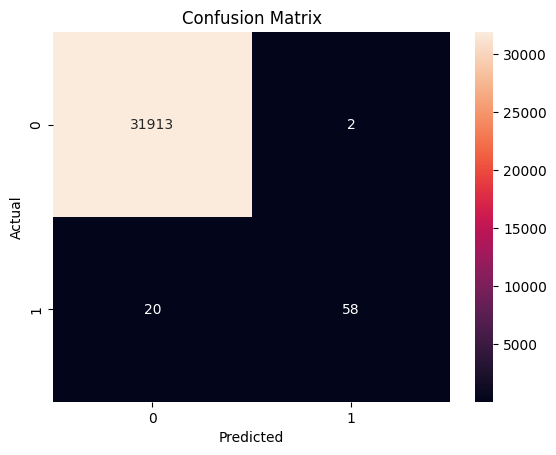

In [ ]:
# Plot confusion matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()